# Лабораторная работа №5. Визуализация данных

In [1]:
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

print(f"Python version: {sys.version}")
print(f"Numpy version: {np.version.version}")
print(f"Matplotlib version: {mpl.__version__}")

%matplotlib inline

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Numpy version: 2.0.2
Matplotlib version: 3.10.0


Задача **1**

Постройте два линейных графика функции $y=\frac{2}{x}+3$ на одной оси координат, первый для диапазона x=[-10;0], а второй для x=[0;7].

* Графики должны быть помещены на оси с пределами xlim(-10, 10) и ylim(-10, 10), иметь подписи к осям, легенду и заголовок.
* Первый график должен быть красного цвета и нарисован штрихпунктирной линией
* Второй график должен иметь цвет (1.0,0.2,0.3) и нарисован сплошной линией


/tmp/ipykernel_10394/2463650948.py:13: RuntimeWarning: divide by zero encountered in divide
  ax.plot(x1, 2/x1 + 3, color = 'red', linestyle = 'dashed', label='x1')
/tmp/ipykernel_10394/2463650948.py:14: RuntimeWarning: divide by zero encountered in divide
  ax.plot(x2, 2/x2 + 3, color =  (1.0,0.2,0.3), linestyle = 'solid', label='x2')


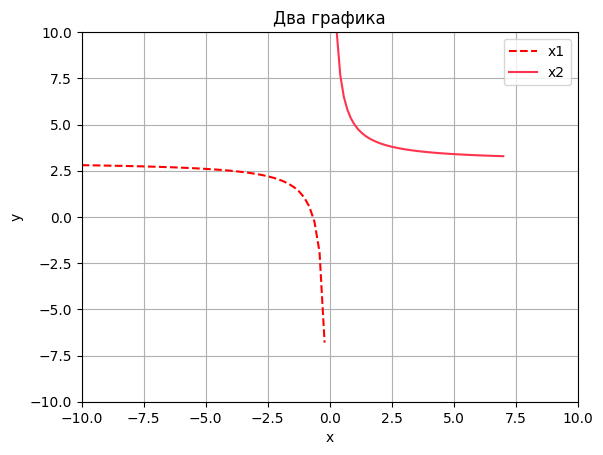

In [2]:
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
ax = plt.axes()
ax.set_title('Два графика')
ax.set_xlabel("x")
ax.set_ylabel("y");
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
x1 = np.linspace(-10, 0)
x2 = np.linspace(0, 7)
ax.plot(x1, 2/x1 + 3, color = 'red', linestyle = 'dashed', label='x1')
ax.plot(x2, 2/x2 + 3, color =  (1.0,0.2,0.3), linestyle = 'solid', label='x2')
ax.legend()
ax.grid()

Задача **2**

Постройте диаграмму рассеяния для набора данных titanic (файл ./data/titanic.csv).

* По оси X - возвраст пассажира (Age)
* По оси Y - стоимость билета (Fare)
* Для выживших пассажиров используется маркер зеленый круг (Survived)
* Для не выживших пассажиров используется маркер красный крест (Survived)
* График должен подписи к осям и легенду и заголовок

Данные для которых не указан возврат или стоимость билета должны быть исключены

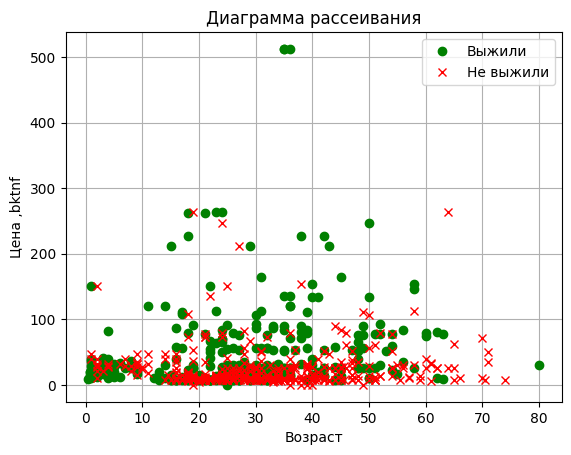

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
titanic_df = pd.read_csv("titanic.csv")
titanic_df = titanic_df.dropna(subset=['Age', 'Fare'])
fig = plt.figure()
ax = plt.axes()
ax.set_title('Диаграмма рассеивания')
ax.set_xlabel("Возраст")
ax.set_ylabel("Цена ,bktnf")
survived = titanic_df[titanic_df['Survived'] == 1]
dead = titanic_df[titanic_df['Survived'] == 0]
plt.plot(survived['Age'], survived['Fare'], 'o', color = 'green', label='Выжили')
plt.plot(dead['Age'], dead['Fare'], 'x', color = 'red', label='Не выжили')
ax.legend()
ax.grid()

Задача **3**

Для первоначального анализа данных часто используются диаграммы рассеяния для всех признаков из набора данных. Это позволяет визуально увидеть зависимости между признаками и выбросы.
Для набора данных [iris](https://ru.wikipedia.org/wiki/%D0%98%D1%80%D0%B8%D1%81%D1%8B_%D0%A4%D0%B8%D1%88%D0%B5%D1%80%D0%B0) постройте на одном холсте 16 диаграмм рассеяния показывающих зависимости между всеми признаками набора ('sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)')

* Холст должен содержать 16 графиков на отдельных осях (см. иллюстрацию к статье в Википедия)
* Цвет маркеров должен зависеть от вида ирисов (iris.target)
* Графики должны иметь подписи к осям, легенду и общий заголовок

Text(0.5, 1, 'Iris')

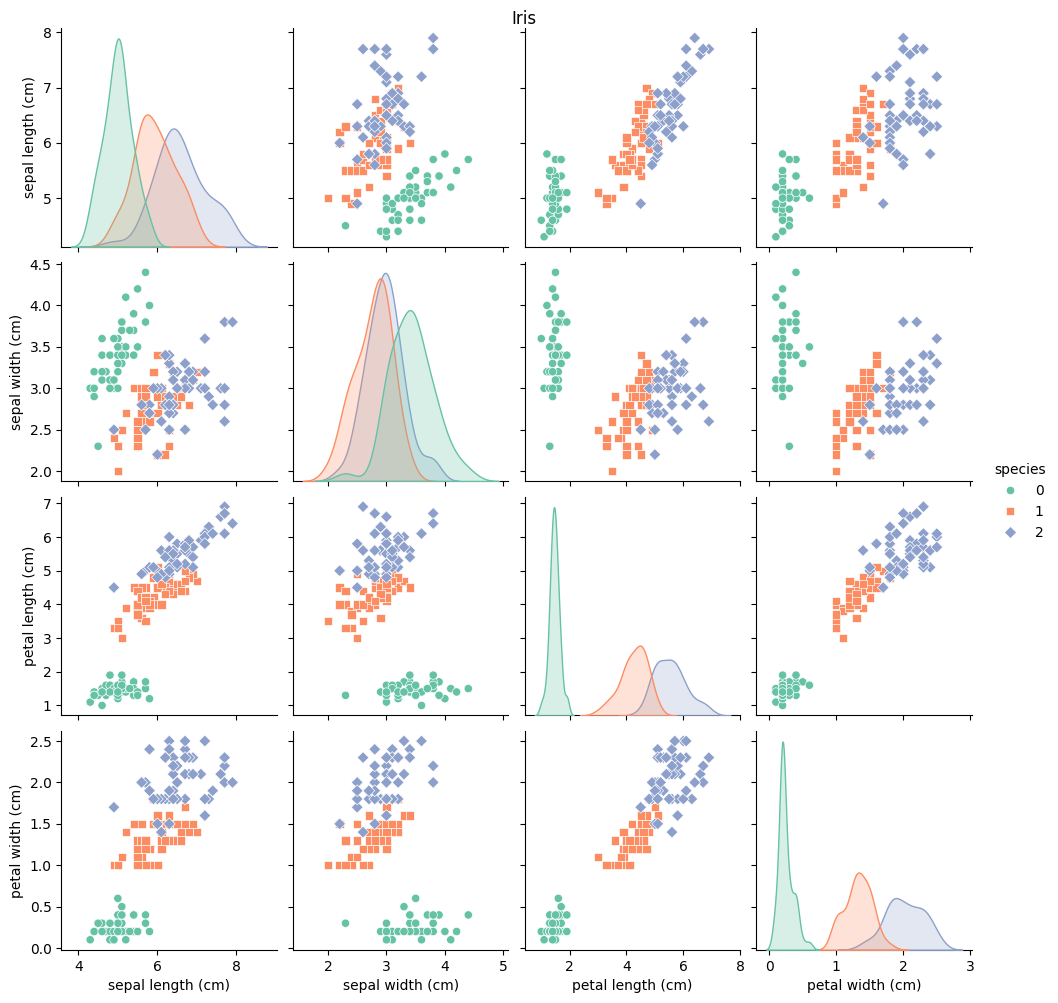

In [4]:
import seaborn as sns
from sklearn.datasets import load_iris
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
sns.pairplot(iris_df, hue='species', palette='Set2', markers=["o", "s", "D"])
plt.suptitle("Iris", y=1)

Задача **4**

Постройте на одном холсте и разный осях следующие распределения для набора данных titanic (./data/titanic.csv):

* Постройте гистограмму распределения пассажиров по возрасту (Age). Интервал 5 лет.
* Постройте гистограмму распределения пассажиров женского пола по стоимости билетов (Fare). Подберите удобный интервал
* График должен иметь подписи к осям, легенду и заголовок

Данные для которых не указан возраст или стоимость билета должны быть исключены

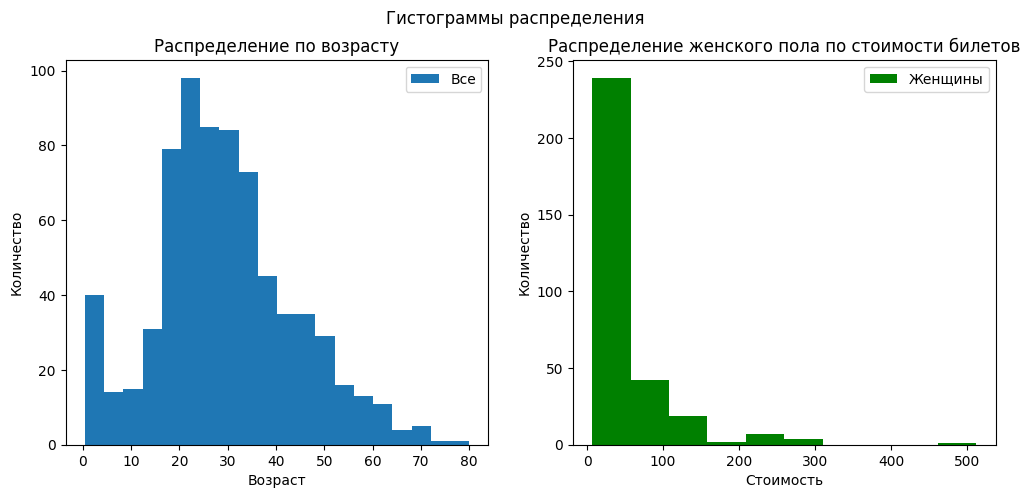

In [8]:
titanic_df = pd.read_csv("titanic.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Гистограммы распределения")
axes[0].hist(titanic_df['Age'], bins = 20, label='Все')
axes[0].set_title("Распределение по возрасту")
axes[0].set_xlabel("Возраст")
axes[0].set_ylabel("Количество")
female = titanic_df[titanic_df['Sex'] == 'female']
axes[1].hist(female['Fare'], bins=10, color='green', label='Женщины')
axes[1].set_title("Распределение женского пола по стоимости билетов")
axes[1].set_xlabel("Стоимость")
axes[1].set_ylabel("Количество")
axes[0].legend()
axes[1].legend()

Задача **5**

Для набора данных для набора данных titanic (./data/titanic.csv) постройте следующую столбчатую диаграмму:

* Диаграмма должна быть вертикальной
* По оси X - класс каюты пассажира (Pclass)
* По оси Y - средняя стоимость за проезд для данного класса (Fare)
* График должен иметь подписи к осям, легенду и заголовок

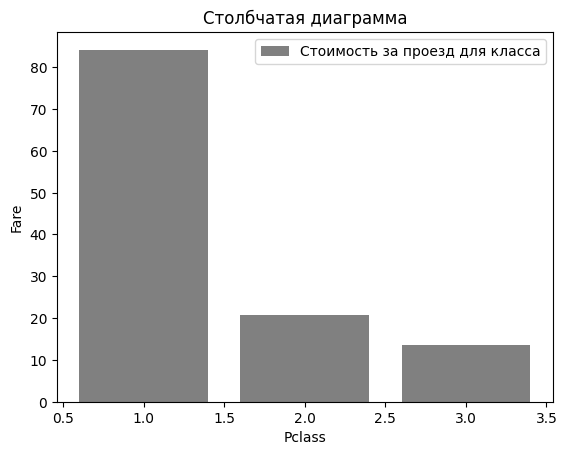

In [10]:
titanic_df = pd.read_csv("titanic.csv")
grouped = titanic_df.groupby('Pclass')['Fare'].mean()
plt.bar(grouped.index, grouped.values, color='grey', label = "Стоимость за проезд для класса")
plt.title("Столбчатая диаграмма")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.legend()

Задача **6**

Для набора данных для набора данных titanic (./data/titanic.csv) постройте следующую столбчатую диаграмму c накоплением:

* Диаграмма должна быть вертикальной
* По оси X - класс каюты пассажира (Pclass)
* По оси Y - количество пассажиров с разбивкой по полу (Sex)
* График должен иметь подписи к осям, легенду и заголовок

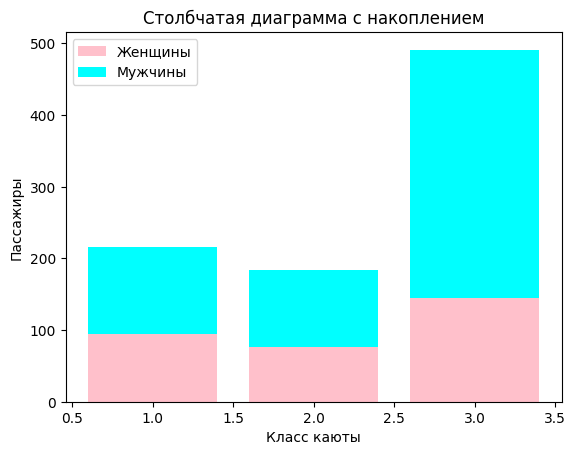

In [11]:
titanic_df = pd.read_csv("titanic.csv")
women = titanic_df[titanic_df['Sex'] == 'female']['Pclass'].value_counts()
men = titanic_df[titanic_df['Sex'] == 'male']['Pclass'].value_counts()
plt.bar(women.index, women, label="Женщины", color="pink")
plt.bar(men.index, men, bottom=women, label="Мужчины", color="cyan")
plt.title("Столбчатая диаграмма с накоплением")
plt.xlabel("Класс каюты")
plt.ylabel("Пассажиры")
plt.legend()

Задача **7**

Для набора данных iris постройте круговую диаграмму

* Диаграмма должна иметь 3 сектора отражающих долю ирисов данного вида в наборе
* Сектор с максимальной долей долен быть выдвинут
* График должен иметь подписи к осям, легенду и заголовок

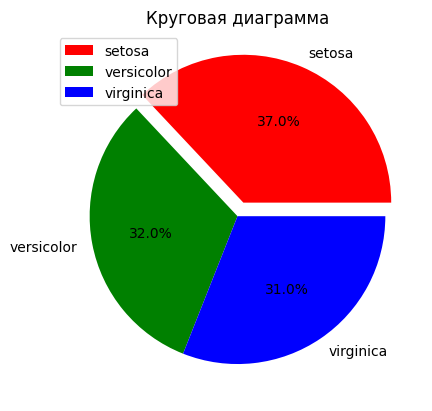

In [12]:
from sklearn.datasets import load_iris
iris = load_iris()
target_series = pd.Series(iris.target)
freq_table = target_series.sample(100, random_state = 42).value_counts()
plt.pie(
    freq_table,
    labels=[iris.target_names[i] for i in freq_table.index],
    colors=["red", "green", "blue"],
    autopct="%.1f%%",
    explode=[0.1, 0, 0]
    )
plt.title("Круговая диаграмма")
plt.legend()

Задача **8**

Использую библиотеку [Seaborn](https://seaborn.pydata.org/) постройте гистограмму для возраста пассажиров "Титаника"

<Axes: xlabel='Age', ylabel='Count'>

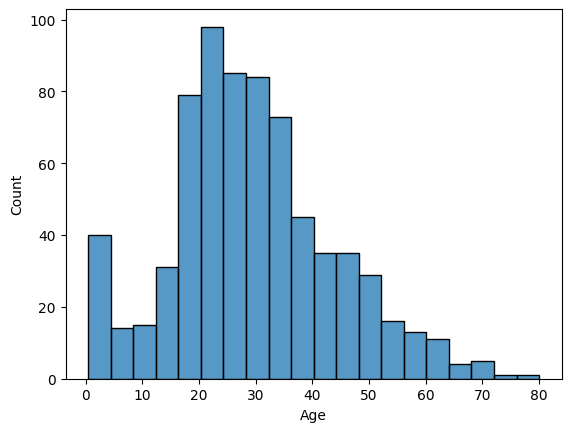

In [14]:
sns.histplot(titanic_df['Age'], bins = 20)

## Вопросы


1. Для чего используется диаграмма рассеяния?
```
Диаграмма рассеяния (scatter plot) используется для визуализации связи между
двумя непрерывными числовыми переменными. Она помогает выявить корреляцию
(положительную, отрицательную или отсутствие связи), кластеры (группы похожих
точек) и выбросы в данных. Каждая точка на графике соответствует одному
наблюдению с координатами (X, Y).
```
2. Что такое гистограмма, чем он отличается от столбчатой диаграммы?
```
Гистограмма — это график распределения одной непрерывной числовой переменной.
Данные разбиваются на интервалы (бины), и высота столбца показывает количество
попаданий в этот интервал. Столбцы в гистограмме всегда соприкасаются (нет
зазоров), так как шкала непрерывна.
Столбчатая диаграмма (bar chart) используется для сравнения значений по
категориальным данным (например, количество пассажиров по классам или портам).
Здесь столбцы разделены промежутками, так как категории дискретны и не имеют
непрерывной связи друг с другом.
Главное отличие: Гистограмма показывает распределение непрерывных данных (важна
ширина бина), а столбчатая диаграмма сравнивает величины по категориям.
```
3. Как задать цвет линии в линейном графике Matplotlib?
```
Цвет линии задается параметром color (или сокращенно c) в функции построения.
Пример: plt.plot(x, y, color='red') или plt.plot(x, y, 'r') (где 'r' — код
красного цвета). Также можно использовать HEX-коды ('#FF5733') или названия
цветов на английском.
```
4. Чем класс plt.Figure отличается от объекта  plt.Axes?
```
Figure — это весь холст или окно, содержащее график. Это контейнер самого
верхнего уровня, в который могут входить один или несколько графиков,
заголовки, легенды и т.д.
Axes — это сама область построения графика (оси X и Y, данные, сетка, подписи)
внутри Figure. Один Figure может содержать несколько объектов Axes
(подграфиков).
```
5. Matplotlib не позволяет управлять типом маркера scatter графика. Да или нет?
```
Нет. Matplotlib полностью позволяет управлять типом маркера. В функции plt.
scatter() или plt.plot() для этого используется параметр marker. Доступны
десятки вариантов: точки (.), кружки (o), квадраты (s), треугольники (^), ромбы
(D) и многие другие.
```
6. Matplotlib единственная библиотека для построения графиков в Python. Да или нет?
```
Нет. В Python существует множество библиотек для визуализации данных. Самые
популярные альтернативы и дополнения: Seaborn (статистические графики на базе
Matplotlib), Plotly (интерактивные графики), Bokeh, Altair, Pygal и
специализированные библиотеки вроде Folium (для карт).
```
7. Matplotlib не позволяет сохранить график в виде файла, нужно делать скриншот?
```
Нет. В Matplotlib есть специальная функция plt.savefig('filename.png'), которая
сохраняет график в файл в высоком качестве. Поддерживаются форматы PNG, JPG,
PDF, SVG, EPS и другие. Делать скриншот не только не нужно, но и не
рекомендуется из-за потери качества.
```
8. В наборе данных iris представлены 4 вида ирисов. Да или нет?
```
Нет. В классическом наборе данных Iris (Фишерa) представлены 3 вида ирисов:
Iris setosa, Iris versicolor и Iris virginica. Всего 150 наблюдений (по 50 на
каждый вид).
```
9. Для всех пассажиров "Титаника" указан возраст. Да или нет?
```
Нет. В предоставленном файле titanic.csv в столбце Age присутствуют пропущенные
значения (пустые ячейки между запятыми). Например, у пассажира Моран (строка 6)
или Вильямс (строка 18) возраст не указан. Всего пропущено около 177 значений
из 891.
```
10. Как на одном холсте может располагаться не более 16 диаграмм, это обусловлено тем что размер диаграммы нельзя изменить и более мелкие графики попросту не будут видны.
```
Это утверждение неверно.
Во-первых, технического ограничения именно на 16 диаграмм в Matplotlib не
существует. Вы можете создать сетку графиков (subplots) практически любого
размера (например, 10x10 = 100 графиков), используя plt.subplots().
Во-вторых, размер диаграммы (холста) можно изменить. При создании фигуры можно
задать параметры figsize=(ширина, высота) в дюймах. Если вам нужно разместить
много мелких графиков, вы просто увеличиваете общий размер фигуры, чтобы они
оставались читаемыми. Ограничение накладывает лишь здравый смысл и читаемость,
а не жесткий лимит библиотеки.
```